#  &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp;                                                      Boston Housing Model 
[Click Here & Download Dataset](https://www.kaggle.com/competitions/boston-housing/data)

<a href="https://drive.google.com/file/d/1U4FUs7IDJ7NPtkgYeK_Q2x1pfAj5pyr7/view?usp=drive_link" target="_blank">Dataset Overview</a>

In [36]:
train_path = r"C:\Users\SUSHIL KUMAR SAHOO\Downloads\DATASETS\Kaggle\Boston_housing\train.csv"
test_path = r"c:\Users\SUSHIL KUMAR SAHOO\Downloads\DATASETS\Kaggle\Boston_housing\test.csv"

In [37]:
# Importing Libraries Here
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
train_df = pd.read_csv(train_path)
train_df.columns

Index(['ID', 'crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad',
       'tax', 'ptratio', 'black', 'lstat', 'medv'],
      dtype='object')

In [39]:
Feature_Column = ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad','tax', 'ptratio', 'black', 'lstat']

### Part 1 :

In [40]:
train_df.head()

,ID,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
3,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
4,7,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9


In [41]:
train_df.shape

(333, 15)

In [42]:
def basic_summary(df):
    summary_info = {
        "missing_values": df.isnull().sum(),
        "dtypes": df.dtypes,
        "stats": df.describe().T
    }
    print("="*200)
    print(f"Missing Values : \n{summary_info['missing_values']}")
    print("="*200)
    print(f"Data Type : \n{summary_info['dtypes']}")
    print("="*200)
    print(f"Statistics : \n{summary_info['stats']}")


basic_summary(train_df)

Missing Values : 
ID         0
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
black      0
lstat      0
medv       0
dtype: int64
Data Type : 
ID           int64
crim       float64
zn         float64
indus      float64
chas         int64
nox        float64
rm         float64
age        float64
dis        float64
rad          int64
tax          int64
ptratio    float64
black      float64
lstat      float64
medv       float64
dtype: object
Statistics : 
         count        mean         std        min        25%        50%  \
ID       333.0  250.951952  147.859438    1.00000  123.00000  244.00000   
crim     333.0    3.360341    7.352272    0.00632    0.07896    0.26169   
zn       333.0   10.689189   22.674762    0.00000    0.00000    0.00000   
indus    333.0   11.293483    6.998123    0.74000    5.13000    9.90000   
chas     333.0    0.060060    0.237956    0.00000    0.00000    0.00000  

##### Distribution Of Target Feature : (medv)

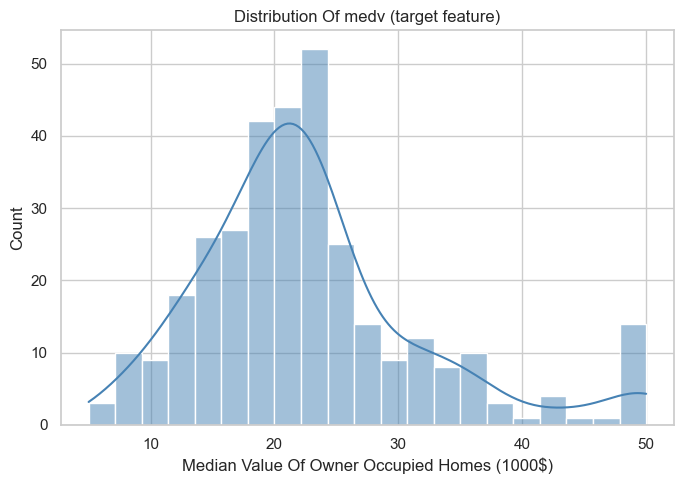

In [43]:
plt.figure(figsize=(7,5))
sns.histplot(x=train_df["medv"],kde=True,color="#4682B4")
plt.title("Distribution Of medv (target feature)")
plt.xlabel("Median Value Of Owner Occupied Homes (1000$)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

- Look's like the above follows a normal distribution .

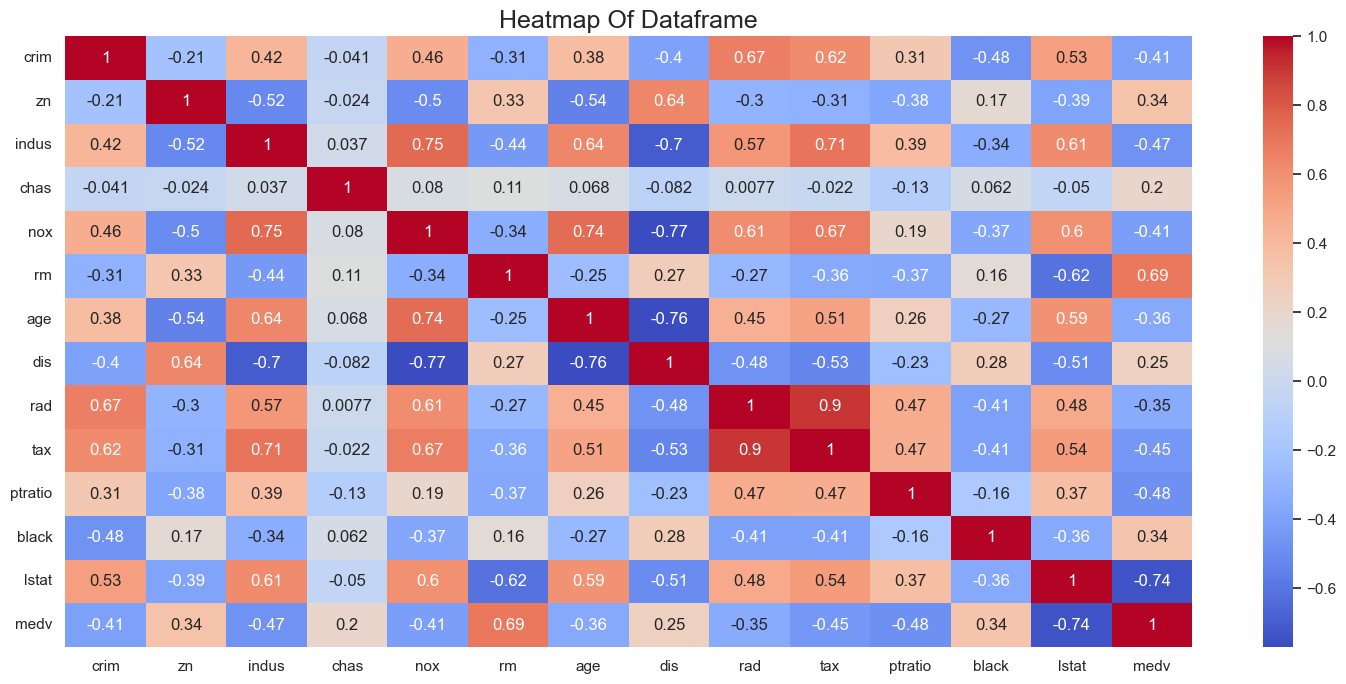

In [44]:
corr = train_df.drop(axis=1,columns=["ID"],).corr()

plt.figure(figsize=(15,7))
sns.heatmap(corr,cmap='coolwarm',annot=True)
plt.title("Heatmap Of Dataframe",fontsize=18)
plt.tight_layout()
plt.show()

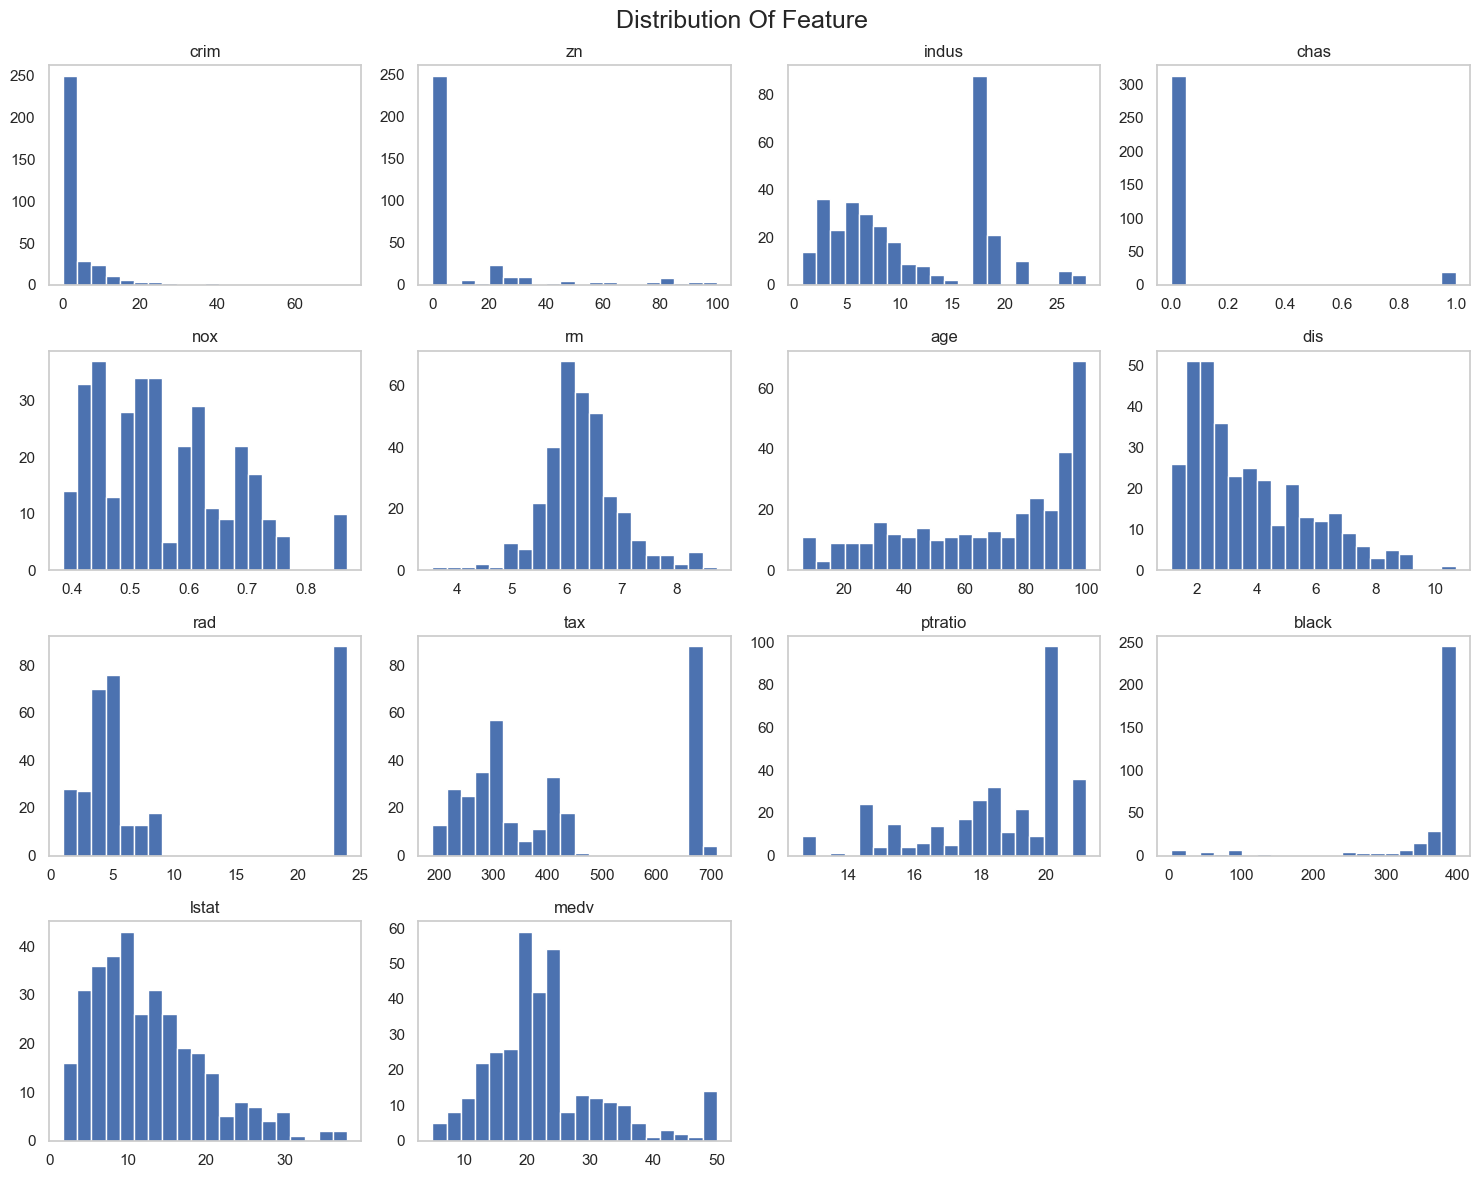

In [45]:
train_df.drop(axis=1,columns=["ID"]).hist(bins=20, grid=False, figsize=(15, 12))
plt.suptitle("Distribution Of Feature",fontsize=18)
plt.tight_layout()
plt.show()

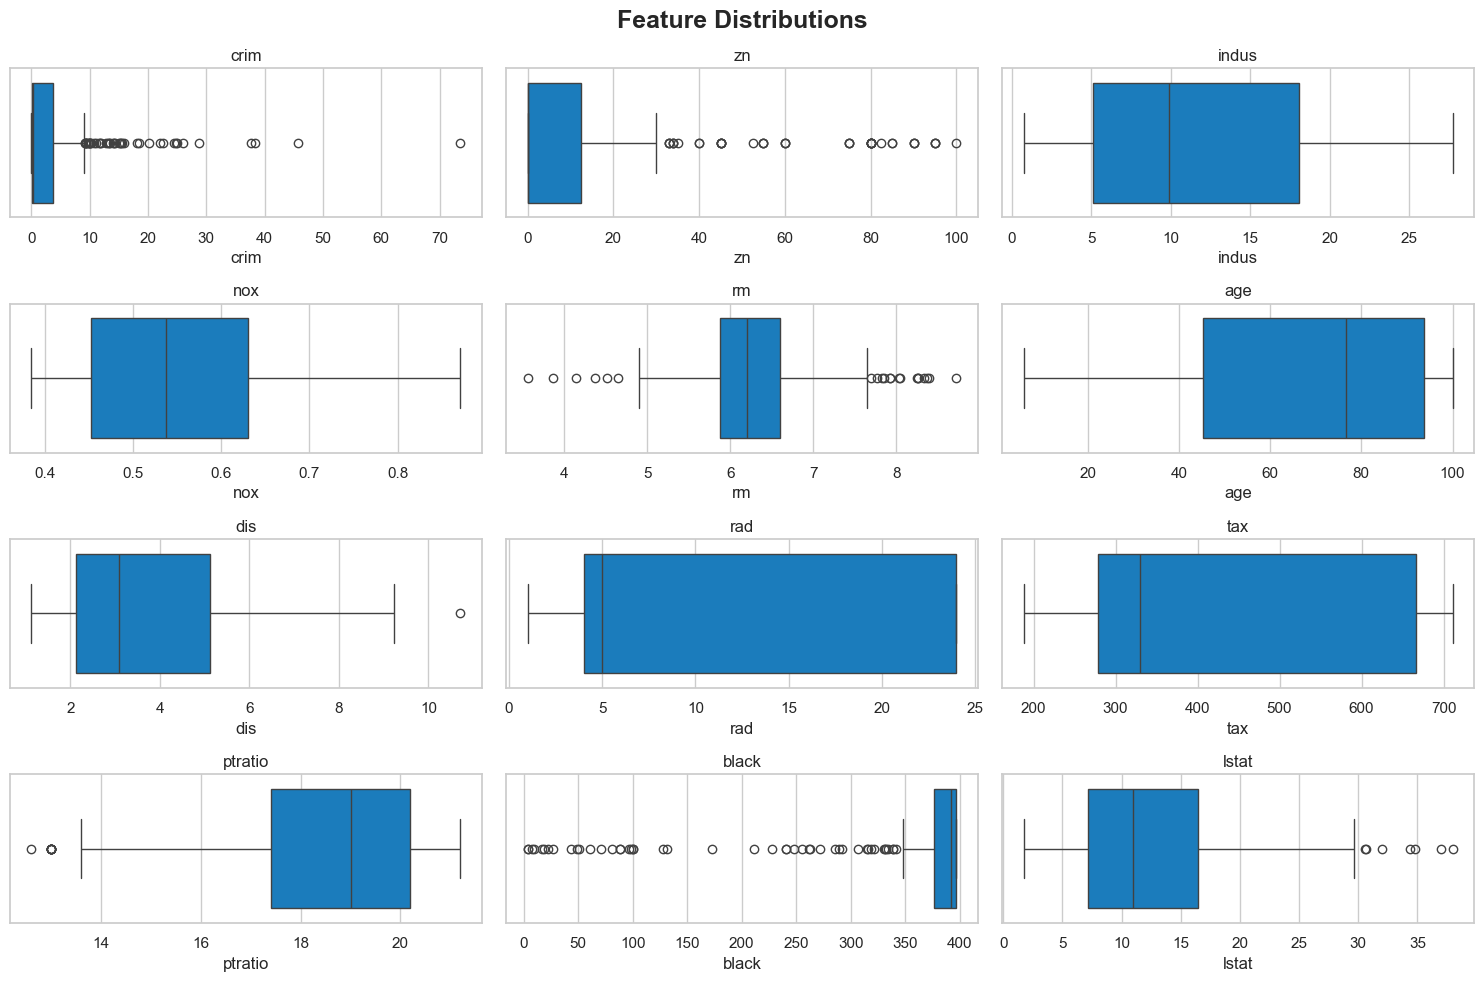

In [46]:
sns.set_theme(style="whitegrid")
numeric_features = train_df.drop(columns=["ID","chas",'medv']).columns
plt.figure(figsize=(15,10))
# Plot each feature
for i, col in enumerate(numeric_features,1):
    plt.subplot(4,3,i)
    sns.boxplot(x=train_df[col],  color="#0081d7")
    plt.title(col)
plt.suptitle("Feature Distributions", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

### Part 2 :

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.linear_model import SGDRegressor

In [48]:
# Separating target from train
x_train_full = train_df.drop(columns=["ID",'medv'])
y_train_full = train_df['medv']

In [49]:
x_train_split,x_test_split,y_train_split,y_test_split = train_test_split(
    x_train_full,y_train_full,test_size=0.2,random_state=42
)

In [50]:
numeric_features = train_df.drop(columns=["ID","rad",'chas','medv']).columns.tolist()
categorical_features = train_df.drop(columns=numeric_features).drop(columns=["ID",'medv']).columns.tolist()
print(categorical_features)

['chas', 'rad']


In [51]:
numeric_transformers = StandardScaler()
categorical_transformers = OneHotEncoder(handle_unknown='ignore',drop='first')

In [52]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num',numeric_transformers,numeric_features),
        ('cat',categorical_transformers,categorical_features)
    ],
    remainder='passthrough'
)

In [53]:
# Scale the split :
x_train_processed = preprocessor.fit_transform(x_train_split)
x_test_processed = preprocessor.transform(x_test_split)

In [55]:
import numpy as np

In [58]:
train_arr = np.c_[x_train_processed,np.array(y_train_split)]
train_arr[0]

array([-0.43566892, -0.47770707, -0.852503  , -0.35944863, -0.40714446,
       -0.78864442,  0.53779943, -1.07184691,  0.80858773,  0.42052006,
       -0.3762768 ,  0.        ,  0.        ,  0.        ,  0.        ,
        1.        ,  0.        ,  0.        ,  0.        ,  0.        ,
       19.        ])

In [ ]:
print(f"x train processed shape : {x_train_processed.shape}")
print(f"x test processed shape : {x_test_processed.shape}")

x train processed shape : (266, 20)
x test processed shape : (67, 20)


In [ ]:
sgd_reg = SGDRegressor(
    max_iter=1000,
    eta0=0.01,
    random_state=42
)

In [ ]:
sgd_reg.fit(x_train_processed,y_train_split)

,loss,'squared_error'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,random_state,42


In [ ]:
# # y = mx + c
# sgd_reg.coef_ # gives the slope(m) of 20 feature
# sgd_reg.intercept_ # c

### Test Model :

In [ ]:
y_test_predict = sgd_reg.predict(x_test_processed)
y_train_predict = sgd_reg.predict(x_train_processed)

In [ ]:
def plot_actual_vs_predicted(y_actual,y_predict):
    if isinstance(y_actual,pd.Series):
        y_actual = y_actual.values

    plt.figure(figsize=(12,7))
    
    plt.plot(y_actual,label='Actual Values',linewidth=2,color='#004c6d')
    plt.plot(y_predict,label="Predicted Values",color='#ff7c43',linestyle='--',linewidth=2)

    plt.title('Actual vs. Predicted Values Over Index (Trend Comparison)',fontsize=18,fontweight='bold')
    plt.xlabel('Data Index')
    plt.ylabel('Median Home Value')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()    
    

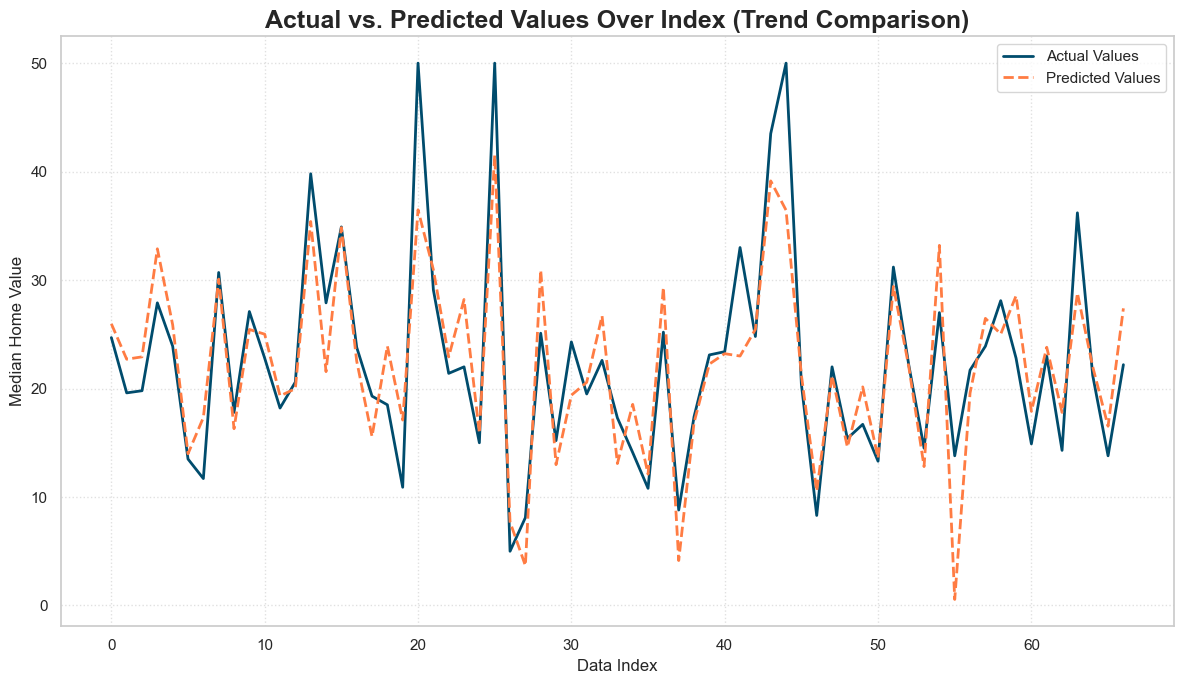

In [ ]:
plot_actual_vs_predicted(y_test_split,y_test_predict)

### Evaluation :

In [ ]:
from sklearn.metrics import mean_squared_error

In [ ]:
mse_train = mean_squared_error(y_train_split,y_train_predict)
print(f"MSE (Train) : {mse_train}")

mse_test = mean_squared_error(y_test_split,y_test_predict)
print(f"MSE (Test) : {mse_test}")

MSE (Train) : 22.10430713998983
MSE (Test) : 21.3468967417432


- From the above evaluation we see it's an ideal fit (random_state = 42)

- Because MSE is squared, you can take the square root (RMSE) to put the error back into the original units of your data. The square root of 26 is roughly 5.1. If you are predicting the Boston housing prices (where values are in $1,000s), your model's predictions are off by an average of about $5,100 on unseen data. If that margin of error is acceptable for your use case, your model is doing fine!  (random_state = 2)

### Save Artefacts :

In [ ]:
import joblib

In [ ]:
model_file_name = 'final_sgd_reg_model.joblib'
preprocessor_file_name = 'data_preprocessor.joblib'

In [ ]:
# joblib.dump(sgd_reg,model_file_name)
# joblib.dump(preprocessor,preprocessor_file_name)

In [ ]:
print(f"Model Saved : {model_file_name}")
print(f"Preprocessor Saved : {preprocessor_file_name}")

Model Saved : final_sgd_reg_model.joblib
Preprocessor Saved : data_preprocessor.joblib
